# NEAT vs HA-NEAT – Final Experiment Analysis

**Experiments:** `multi_task_neat_vs_haneat_final` + `multi_task_haneat_finalv2`  
**Config:** pop=4096, gen=2000, compat=[0.3, 0.5], 5 seeds × 2 compat values per algorithm  
**Tasks:** Hopper (11 obs / 3 act) + Walker2D (17 obs / 6 act)  
**Fitness:** normalized_min = min(norm_hopper, norm_walker2d)

**Sections:**
1. Setup
2. Genome inventory
3. Training dynamics (MLflow)
4. Re-evaluation results
5. Re-evaluation plots
6. Statistical tests + bootstrap CIs
7. Summary

## 1. Setup

In [1]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# ── project root on path ────────────────────────────────────────────────────
PROJECT_ROOT = Path(os.getcwd()).parent
for p in [
    str(PROJECT_ROOT),
    str(PROJECT_ROOT / "text" / "figures"),
]:
    if p not in sys.path:
        sys.path.insert(0, p)

# ── analysis modules ────────────────────────────────────────────────────────
from analysis.merge import collect_genomes, split_by_algorithm
from analysis.stats import (
    compute_tests, compute_normalized_min, format_txt_report,
    REFERENCE_REWARDS, TASKS as STAT_TASKS, _seed_means,
)
from plot_training_curves import (
    load_metrics, setup_matplotlib,
    ALGO_COLORS, ALGO_DISPLAY,
    _group_by_algorithm, _extract_series, _compute_mean_curve,
)
from plot_evaluation_results import (
    plot_evaluation, ALGO_DOT_COLORS,
)

# ── constants ────────────────────────────────────────────────────────────────
EXPERIMENTS  = ["multi_task_neat_vs_haneat_final", "multi_task_haneat_finalv2"]
TASKS        = ["hopper", "walker2d"]

DB_PATH      = PROJECT_ROOT / "mlflow.db"
RESULTS_ROOT = PROJECT_ROOT / "results"

REEVAL_JSON  = (
    PROJECT_ROOT / "analysis" / "outputs"
    / "final_20260418_012803" / "reeval" / "combined.json"
)

FIGURES_DIR  = PROJECT_ROOT / "analysis" / "outputs" / "final" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

setup_matplotlib()
print(f"Project root  : {PROJECT_ROOT}")
print(f"Re-eval JSON  : {REEVAL_JSON}  (exists={REEVAL_JSON.exists()})")
print(f"Figures dir   : {FIGURES_DIR}")

Project root  : /Users/svengoerdes/Projects/Thesisv2/tensorneat
Re-eval JSON  : /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/final_20260418_012803/reeval/combined.json  (exists=True)
Figures dir   : /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/final/figures


## 2. Genome inventory

In [2]:
entries = collect_genomes(str(RESULTS_ROOT), EXPERIMENTS)
groups  = split_by_algorithm(entries)

rows = []
for e in sorted(entries, key=lambda x: (x.algorithm, x.compat or 0, x.seed or 0)):
    rows.append({
        "algorithm" : e.algorithm,
        "seed"      : e.seed,
        "compat"    : e.compat,
        "experiment": e.experiment,
        "size_kb"   : round(os.path.getsize(e.path) / 1024, 1),
        "file"      : e.fname,
    })

df_inv = pd.DataFrame(rows)
print(df_inv.groupby(["algorithm", "compat"]).size().rename("count"))
display(df_inv)

algorithm  compat
ha_neat    0.3       9
           0.5       5
neat       0.3       5
           0.5       5
Name: count, dtype: int64


,algorithm,seed,compat,experiment,size_kb,file
0,ha_neat,7,0.3,multi_task_neat_vs_haneat_final,4.6,ha_neat_normalized_min_pop4096_gen2000_disjoin...
1,ha_neat,7,0.3,multi_task_haneat_finalv2,4.6,ha_neat_normalized_min_pop4096_gen2000_disjoin...
2,ha_neat,21,0.3,multi_task_haneat_finalv2,4.6,ha_neat_normalized_min_pop4096_gen2000_disjoin...
3,ha_neat,42,0.3,multi_task_neat_vs_haneat_final,4.6,ha_neat_normalized_min_pop4096_gen2000_disjoin...
4,ha_neat,42,0.3,multi_task_haneat_finalv2,4.6,ha_neat_normalized_min_pop4096_gen2000_disjoin...
5,ha_neat,75,0.3,multi_task_neat_vs_haneat_final,4.6,ha_neat_normalized_min_pop4096_gen2000_disjoin...
6,ha_neat,75,0.3,multi_task_haneat_finalv2,4.6,ha_neat_normalized_min_pop4096_gen2000_disjoin...
7,ha_neat,123,0.3,multi_task_neat_vs_haneat_final,4.6,ha_neat_normalized_min_pop4096_gen2000_disjoin...
8,ha_neat,123,0.3,multi_task_haneat_finalv2,4.6,ha_neat_normalized_min_pop4096_gen2000_disjoin...
9,ha_neat,7,0.5,multi_task_haneat_finalv2,4.6,ha_neat_normalized_min_pop4096_gen2000_disjoin...


## 3. Training dynamics (MLflow)

In [3]:
METRIC_KEYS = [
    "best_fitness_normalized/hopper",
    "best_fitness_normalized/walker2d",
    "fitness/max",
    "neat/n_species",
    "neat/best_genome_n_nodes",
    "neat/best_genome_n_conns",
]

mlflow_data: dict = {}
for exp in EXPERIMENTS:
    try:
        data = load_metrics(str(DB_PATH), exp, METRIC_KEYS)
        mlflow_data.update(data)
        print(f"  Loaded {len(data)} runs from '{exp}'")
    except SystemExit:
        print(f"  Could not load '{exp}' — skipping.")

algo_groups = _group_by_algorithm(mlflow_data)
print(f"\nTotal runs loaded: {len(mlflow_data)}")
for algo, runs in sorted(algo_groups.items()):
    print(f"  {ALGO_DISPLAY.get(algo, algo):20s}  {len(runs)} run(s)")

  Loaded 14 runs from 'multi_task_neat_vs_haneat_final'
  Loaded 10 runs from 'multi_task_haneat_finalv2'

Total runs loaded: 20
  HA-NEAT               10 run(s)
  NEAT                  10 run(s)


  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/final/figures/training_hopper.pdf


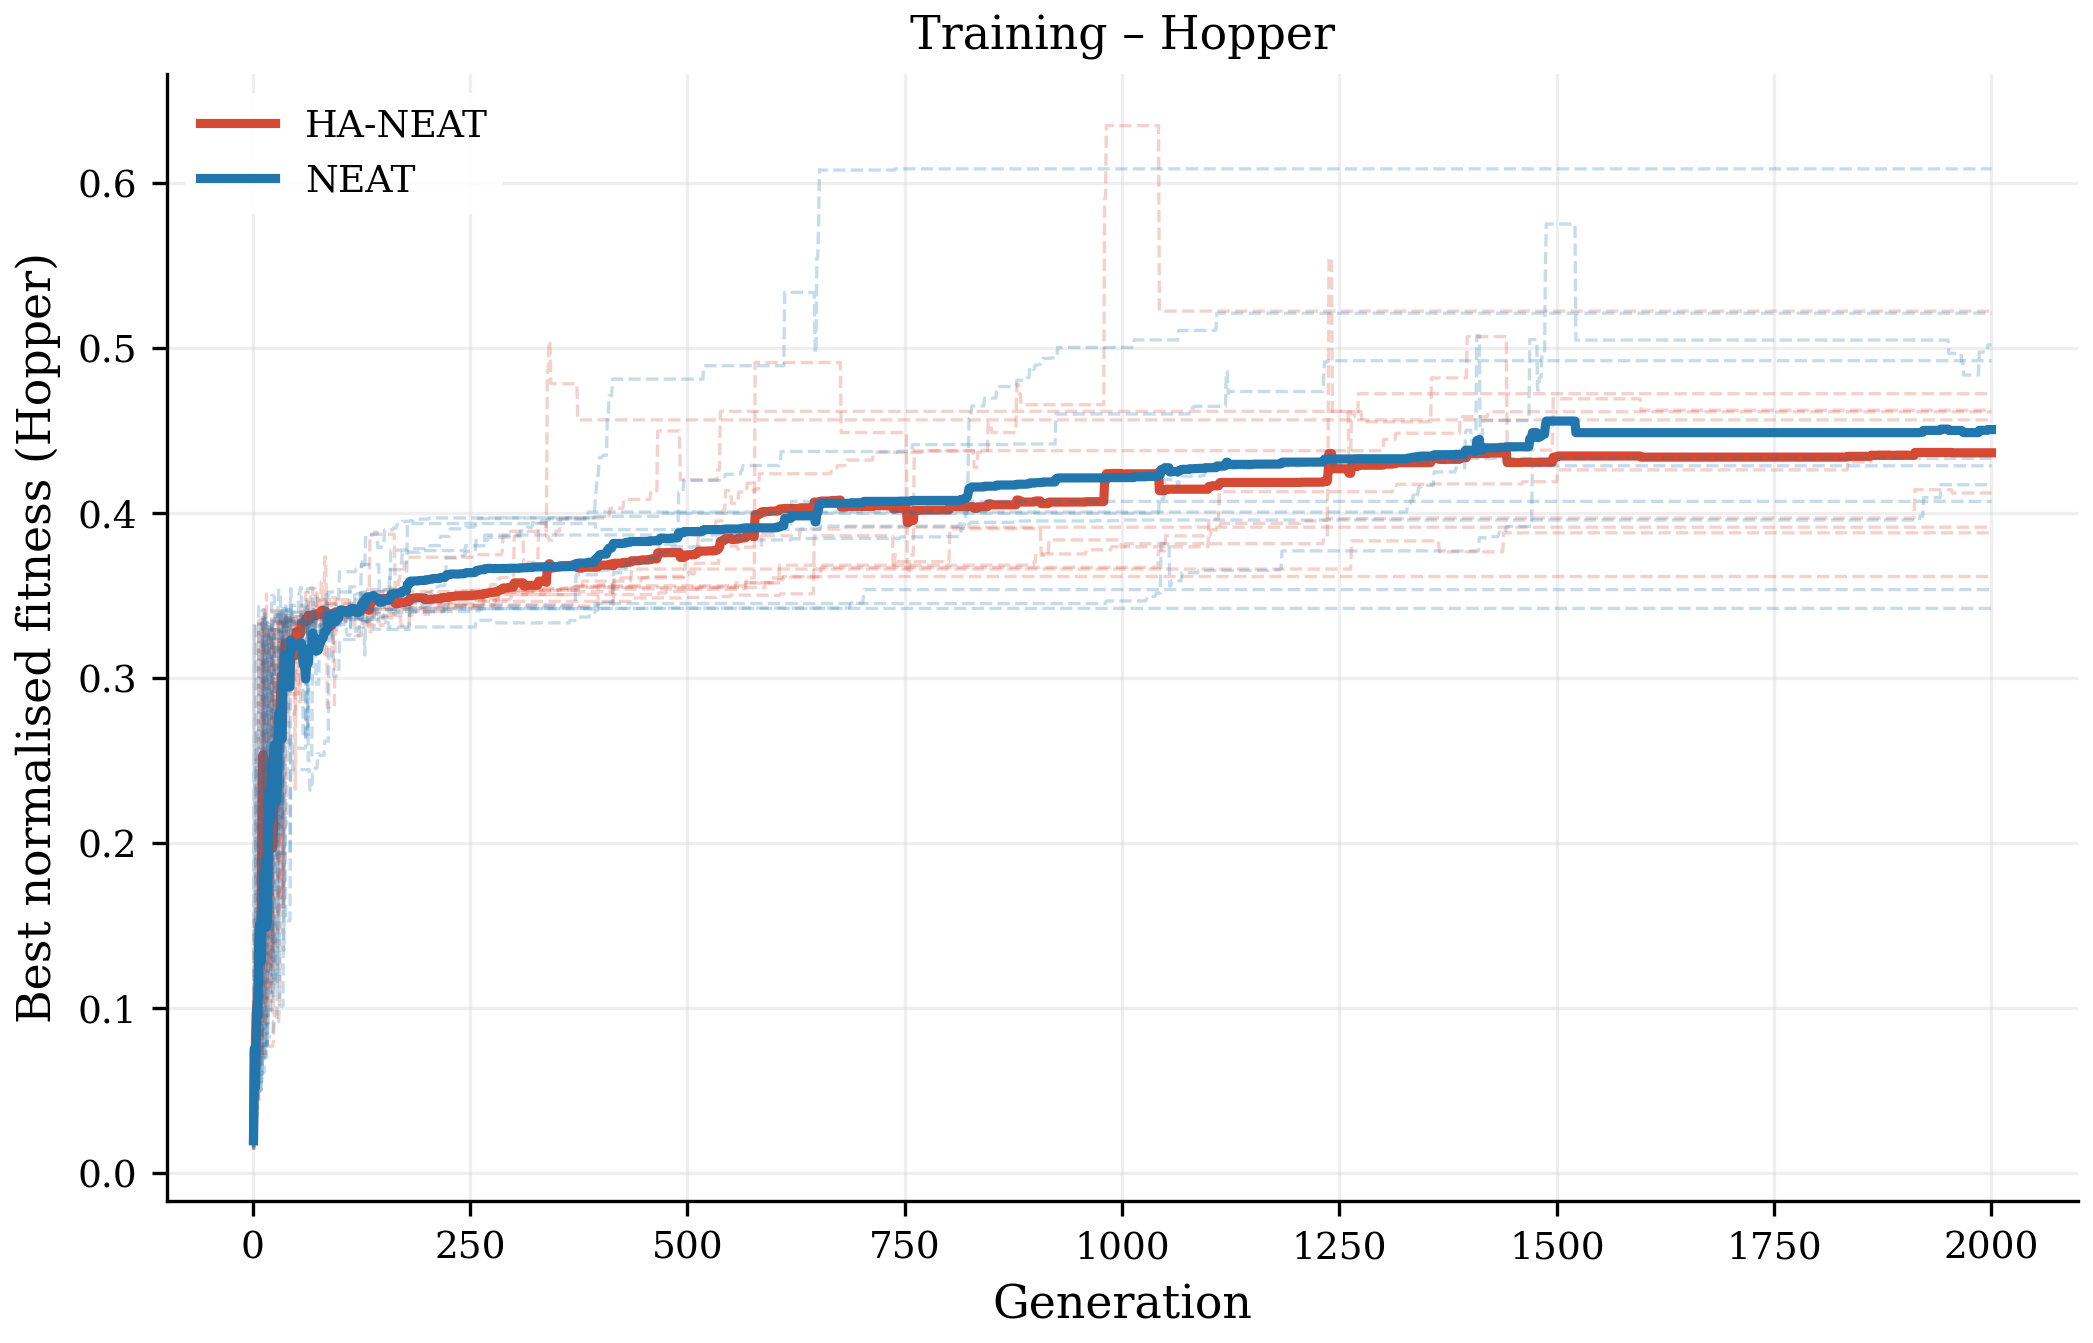

  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/final/figures/training_walker2d.pdf


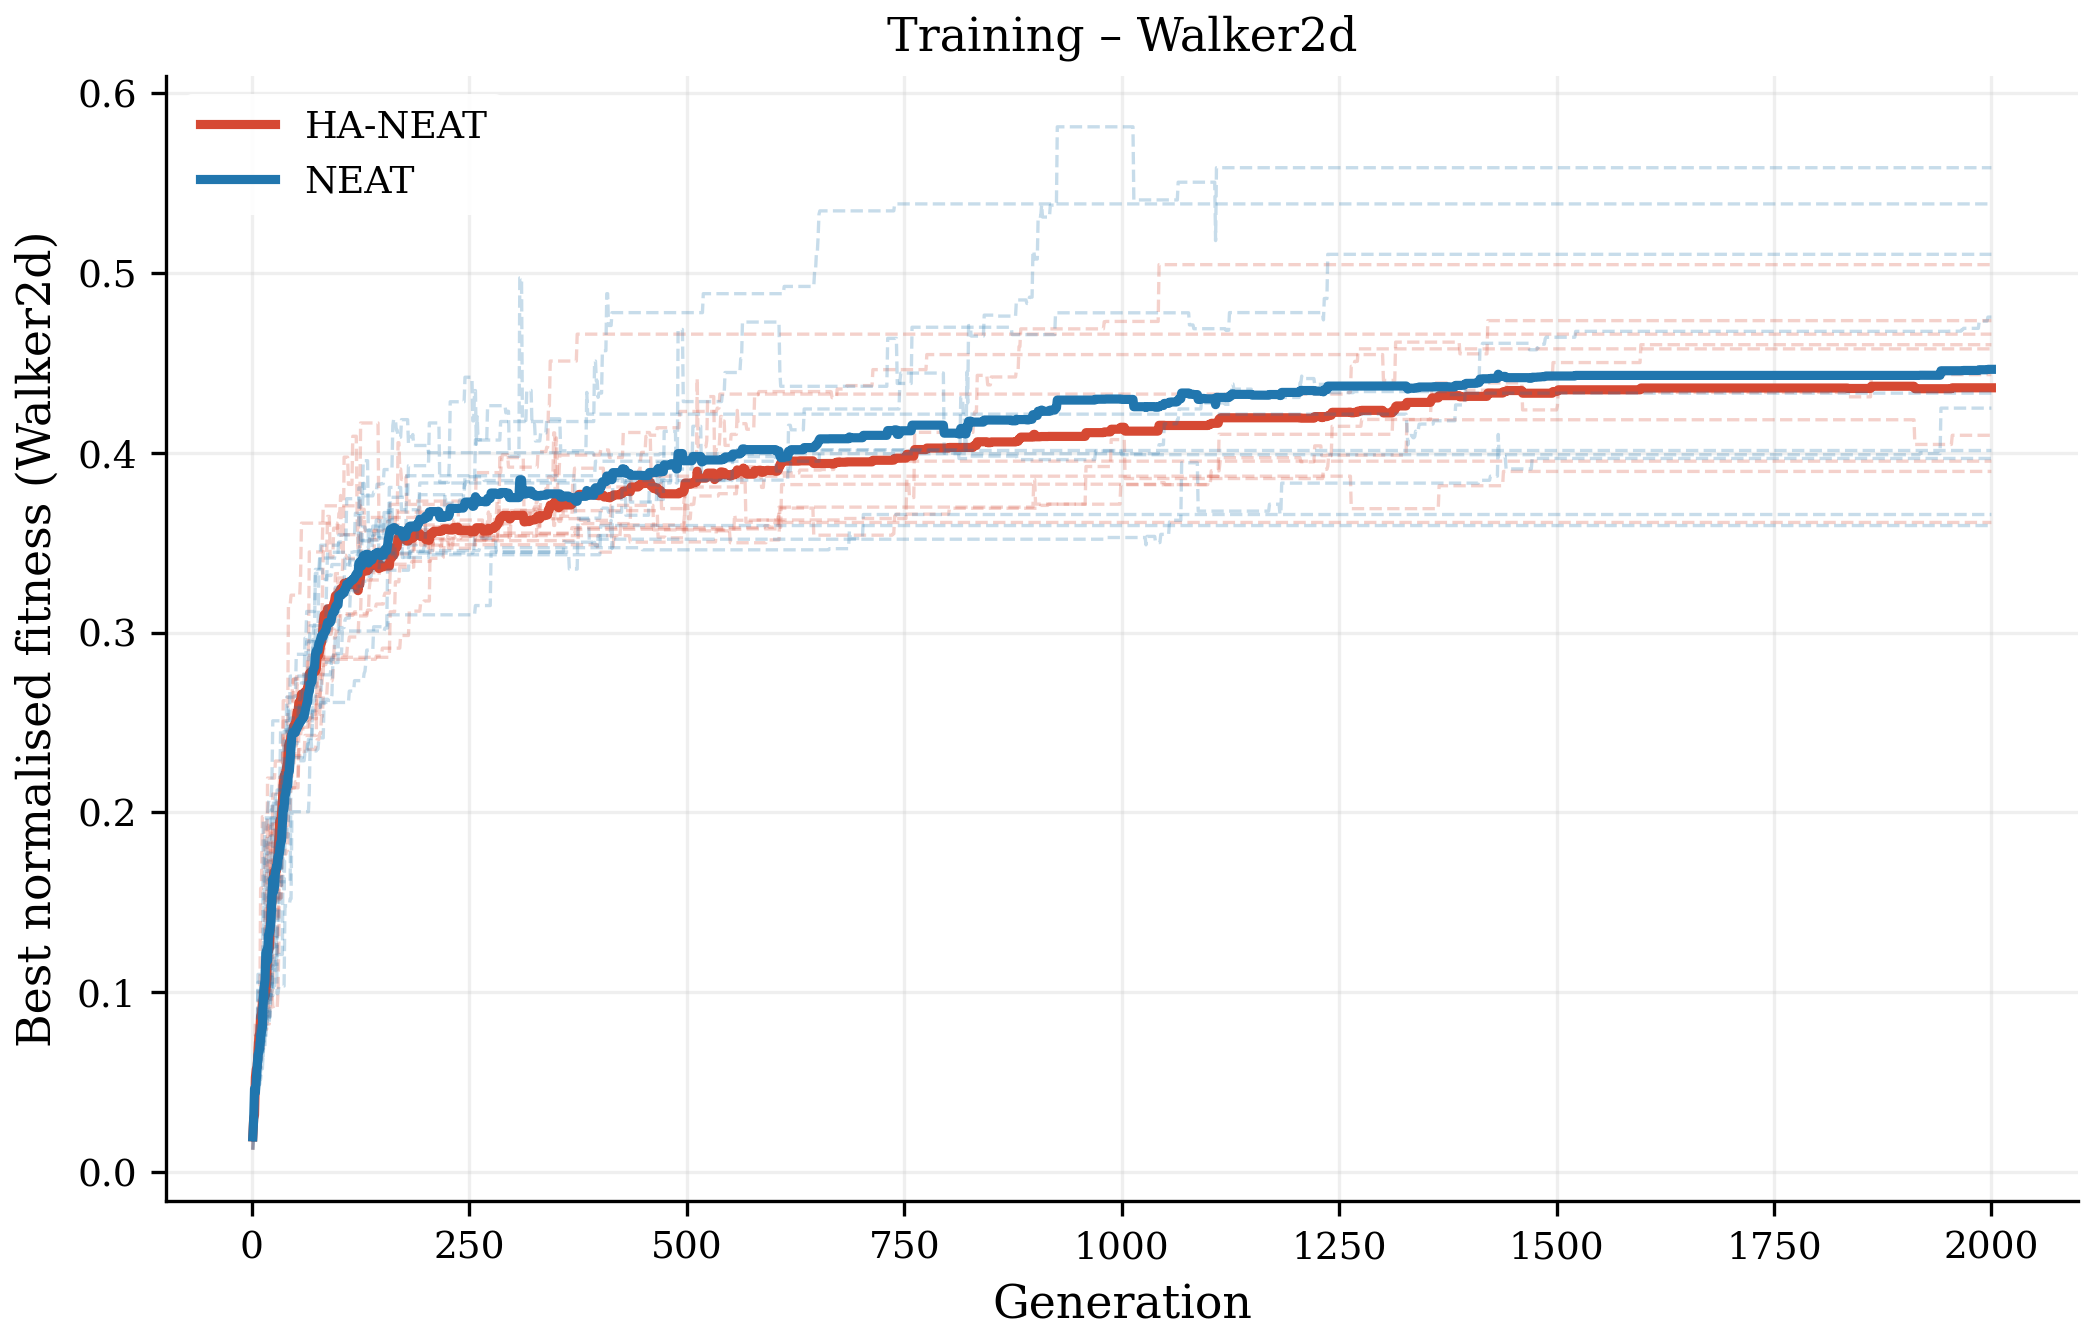

  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/final/figures/training_aggregated.pdf


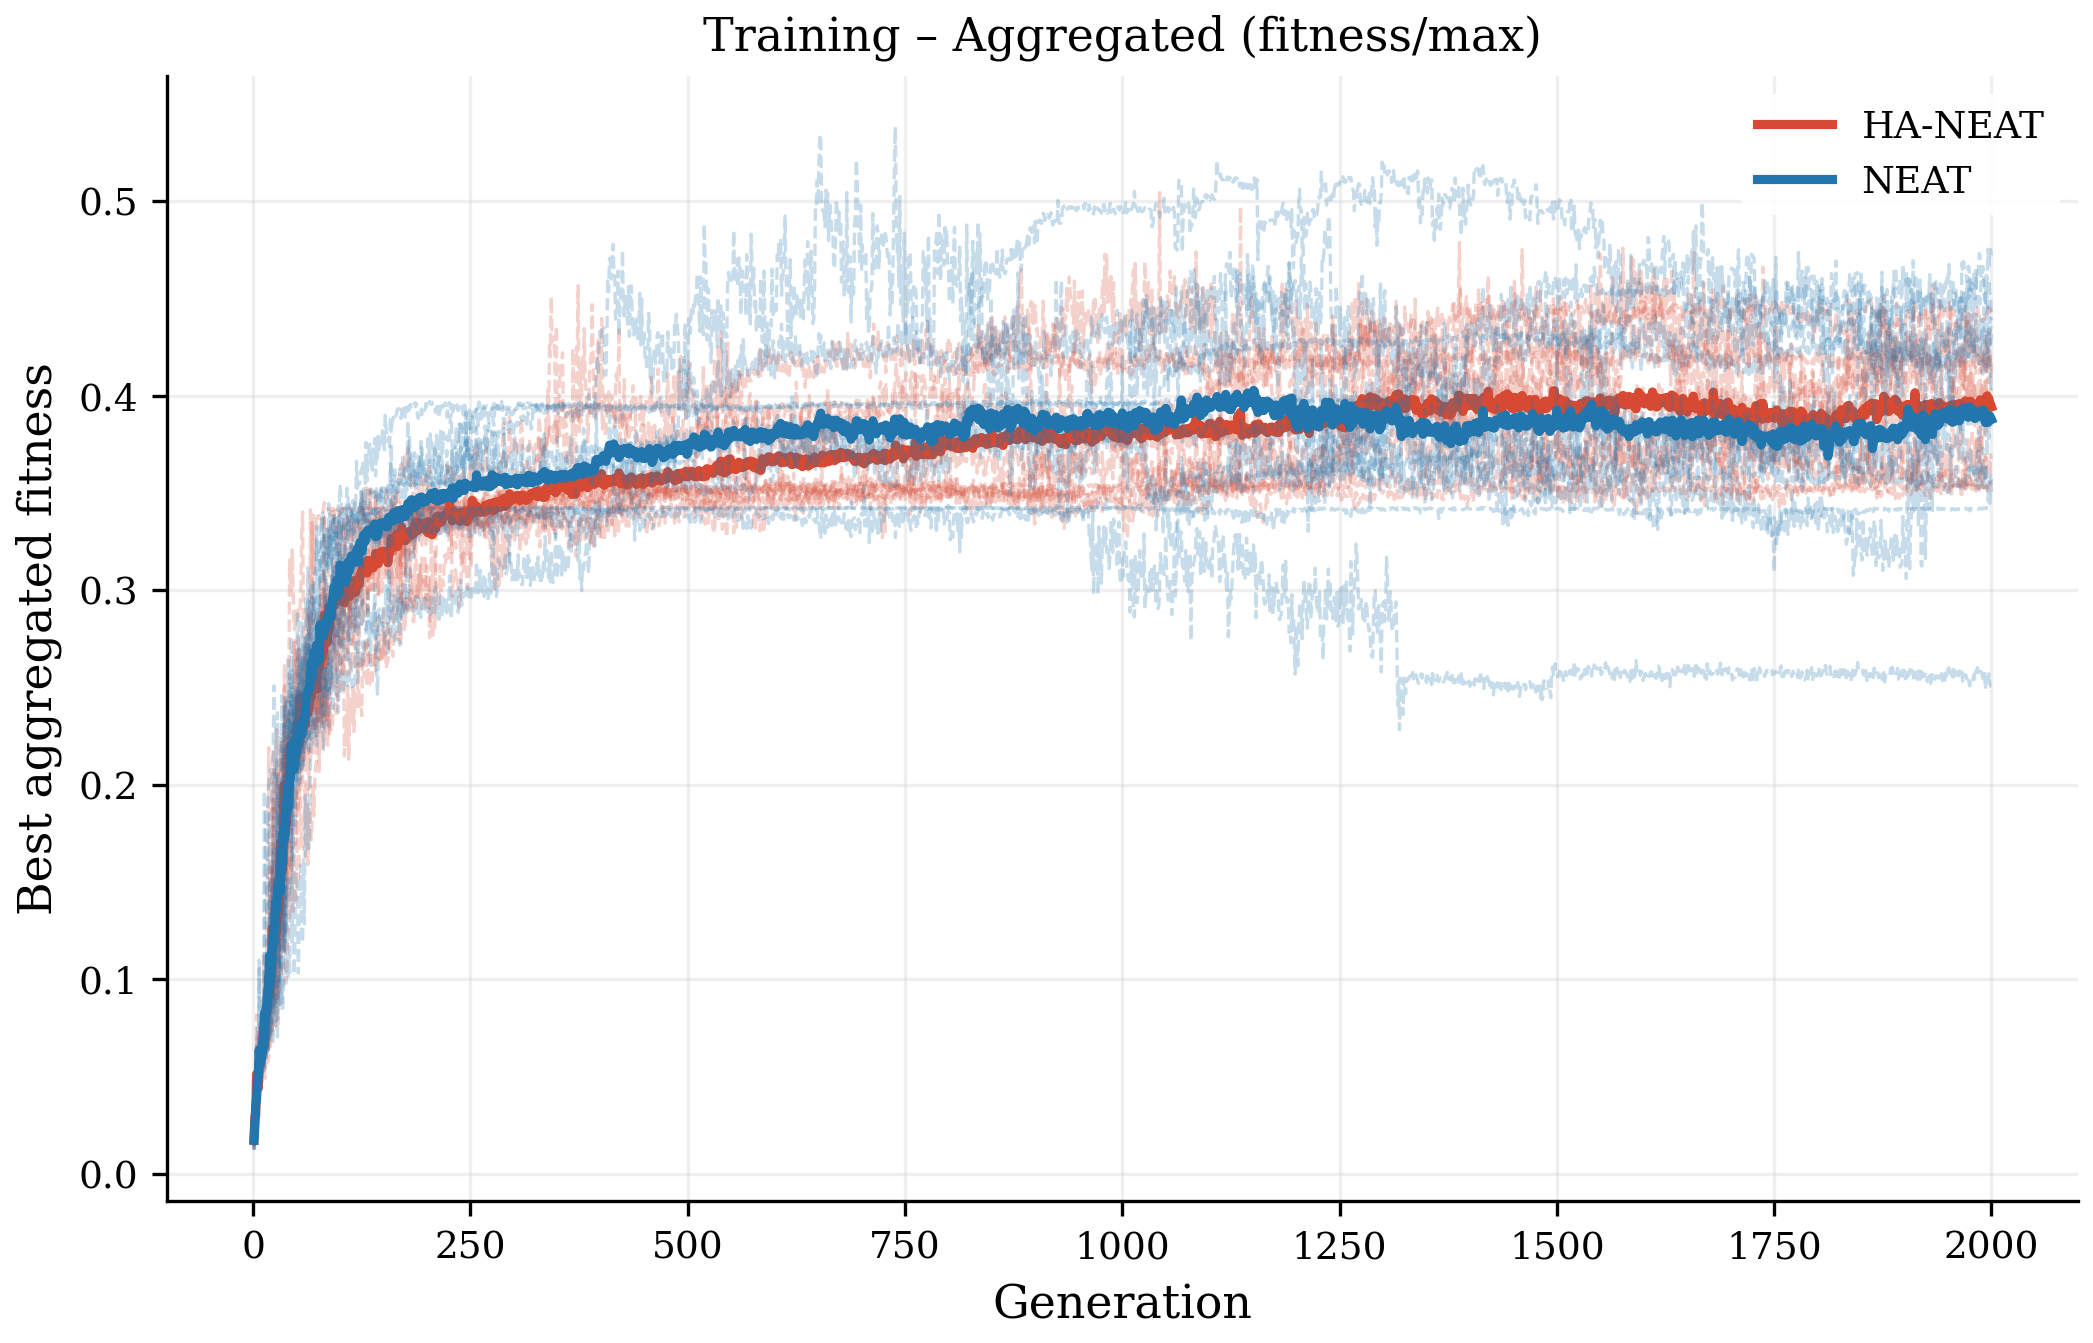

In [4]:
def plot_metric_curves(data, metric_key, ylabel, title, ax=None, save_path=None):
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(7, 4.5))
    else:
        fig = ax.get_figure()

    groups = _group_by_algorithm(data)
    for algo in sorted(groups):
        color = ALGO_COLORS.get(algo, "#555555")
        label = ALGO_DISPLAY.get(algo, algo)
        all_steps, all_vals = [], []
        for run_name in groups[algo]:
            if metric_key not in data[run_name]:
                continue
            steps, vals = _extract_series(data[run_name][metric_key])
            if len(steps) == 0:
                continue
            all_steps.append(steps)
            all_vals.append(vals)
            ax.plot(steps, vals, color=color, alpha=0.25, linewidth=0.8, linestyle="--")
        if all_steps:
            ms, mv = _compute_mean_curve(all_steps, all_vals)
            ax.plot(ms, mv, color=color, linewidth=2.2, label=label)

    ax.set_xlabel("Generation")
    ax.set_ylabel(ylabel)
    ax.set_title(title, pad=6)
    ax.legend(framealpha=0.9, edgecolor="none")
    fig.tight_layout(pad=0.4)

    if save_path:
        fig.savefig(save_path)
        print(f"  Saved: {save_path}")
    if own_fig:
        plt.show()
        plt.close(fig)


for task in TASKS:
    plot_metric_curves(
        mlflow_data,
        f"best_fitness_normalized/{task}",
        ylabel=f"Best normalised fitness ({task.capitalize()})",
        title=f"Training – {task.capitalize()}",
        save_path=FIGURES_DIR / f"training_{task}.pdf",
    )

plot_metric_curves(
    mlflow_data,
    "fitness/max",
    ylabel="Best aggregated fitness",
    title="Training – Aggregated (fitness/max)",
    save_path=FIGURES_DIR / "training_aggregated.pdf",
)

  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/final/figures/genome_complexity.pdf


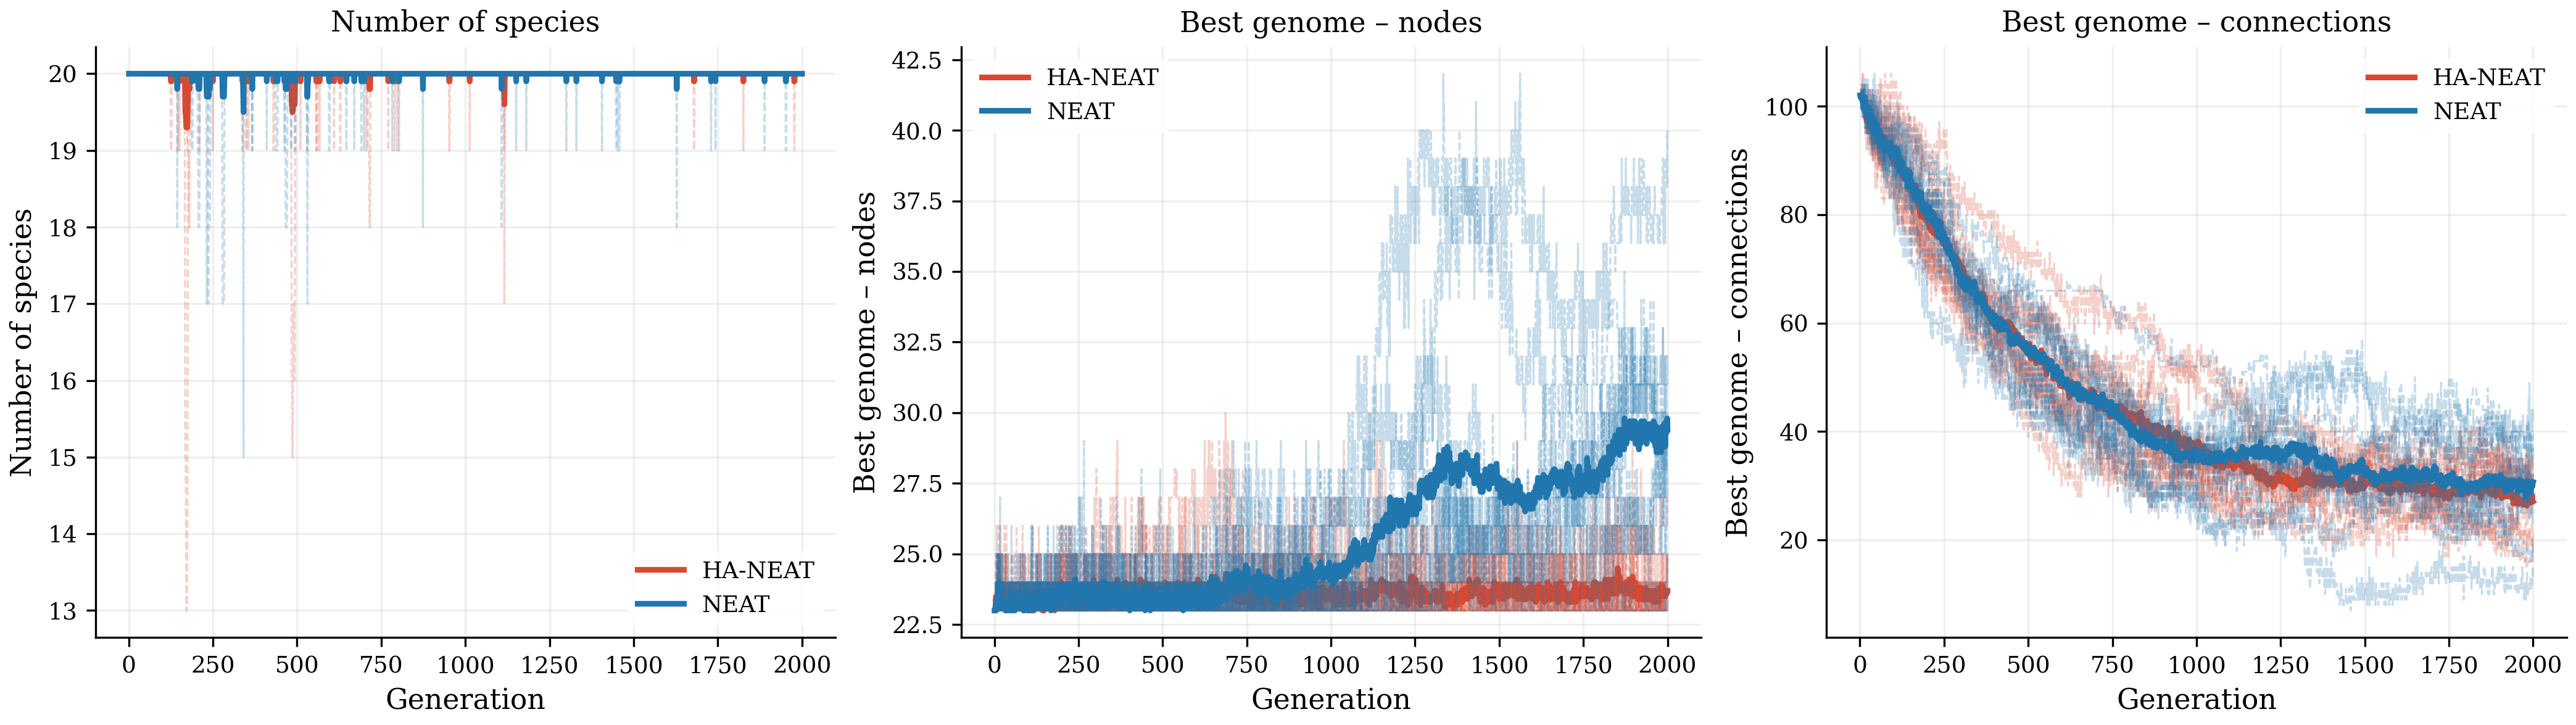


Final-generation genome complexity (mean ± std across seeds):


,Number of species,Best genome – nodes,Best genome – connections
Algorithm,,,
HA-NEAT,20.0 ± 0.0,23.7 ± 1.3,27.1 ± 6.3
NEAT,20.0 ± 0.0,29.4 ± 4.0,30.7 ± 10.0


In [5]:
COMPLEXITY_METRICS = {
    "neat/n_species"          : "Number of species",
    "neat/best_genome_n_nodes": "Best genome – nodes",
    "neat/best_genome_n_conns": "Best genome – connections",
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (metric_key, ylabel) in zip(axes, COMPLEXITY_METRICS.items()):
    plot_metric_curves(mlflow_data, metric_key, ylabel=ylabel, title=ylabel, ax=ax)

fig.tight_layout(pad=0.6)
fig.savefig(FIGURES_DIR / "genome_complexity.pdf")
print(f"  Saved: {FIGURES_DIR / 'genome_complexity.pdf'}")
plt.show()
plt.close(fig)

# Final-generation summary table
summary_rows = []
for algo, run_names in sorted(_group_by_algorithm(mlflow_data).items()):
    label = ALGO_DISPLAY.get(algo, algo)
    row = {"Algorithm": label}
    for metric_key, col_name in COMPLEXITY_METRICS.items():
        final_vals = []
        for rn in run_names:
            if metric_key not in mlflow_data[rn]:
                continue
            steps, vals = _extract_series(mlflow_data[rn][metric_key])
            if len(vals):
                final_vals.append(vals[-1])
        row[col_name] = f"{np.mean(final_vals):.1f} ± {np.std(final_vals, ddof=1):.1f}" if final_vals else "n/a"
    summary_rows.append(row)

df_complexity = pd.DataFrame(summary_rows).set_index("Algorithm")
print("\nFinal-generation genome complexity (mean ± std across seeds):")
display(df_complexity)

## 4. Re-evaluation results

In [6]:
if not REEVAL_JSON.exists():
    raise FileNotFoundError(
        f"Re-evaluation JSON not found: {REEVAL_JSON}\n"
        "Run: uv run python -m analysis.run_final_analysis --skip-sync"
    )

print(f"Loading re-evaluation from:\n  {REEVAL_JSON}")
with open(REEVAL_JSON) as f:
    combined = json.load(f)

meta      = combined["metadata"]
runs_ok   = [r for r in combined["runs"] if "error" not in r]
neat_runs = [r for r in runs_ok if r.get("algorithm") == "neat"]
ha_runs   = [r for r in runs_ok if r.get("algorithm") == "ha_neat"]

print(f"\nMetadata:")
print(f"  experiments : {meta.get('experiments')}")
print(f"  n_eval      : {meta.get('n_eval')} episodes per genome per task")
print(f"  backend     : {meta.get('backend')}")
print(f"  n_genomes   : {meta.get('n_genomes')}")
print(f"  timestamp   : {meta.get('timestamp')}")
print(f"\nSuccessful re-evaluations: NEAT={len(neat_runs)}, HA-NEAT={len(ha_runs)}")

summary = combined.get("summary", {})
rows = []
for algo, label in [("neat", "NEAT"), ("ha_neat", "HA-NEAT")]:
    if algo not in summary:
        continue
    s = summary[algo]
    for task in TASKS:
        if task not in s:
            continue
        t = s[task]
        rows.append({
            "Algorithm"  : label,
            "Task"       : task.capitalize(),
            "Mean reward": f"{t['mean_across_seeds']:.1f} ± {t['std_across_seeds']:.1f}",
            "Mean norm." : f"{t['mean_normalized']:.4f} ± {t['std_normalized']:.4f}",
            "N seeds"    : t["n_seeds"],
        })

df_summary = pd.DataFrame(rows).set_index(["Algorithm", "Task"])
print()
display(df_summary)

Loading re-evaluation from:
  /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/final_20260418_012803/reeval/combined.json

Metadata:
  experiments : ['multi_task_neat_vs_haneat_final', 'multi_task_haneat_finalv2']
  n_eval      : 20 episodes per genome per task
  backend     : mjx
  n_genomes   : 20
  timestamp   : 20260418_035244

Successful re-evaluations: NEAT=10, HA-NEAT=10



Mean reward       Mean norm.  N seeds
Algorithm Task                                              
NEAT      Hopper    1148.9 ± 364.6  0.3830 ± 0.1215       10
          Walker2d  1745.1 ± 586.0  0.3490 ± 0.1172       10
HA-NEAT   Hopper     965.9 ± 339.6  0.3220 ± 0.1132       10
          Walker2d  1515.6 ± 453.4  0.3031 ± 0.0907       10

## 5. Re-evaluation plots

In [7]:
# 5a. Grouped bar charts
combined_labeled = dict(combined)
combined_labeled["metadata"] = dict(combined["metadata"], experiment="multi_task_neat_vs_haneat_final")

plot_evaluation(combined_labeled, TASKS, str(FIGURES_DIR), "pdf", normalized=True)
plot_evaluation(combined_labeled, TASKS, str(FIGURES_DIR), "pdf", normalized=False)

  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/final/figures/multi_task_neat_vs_haneat_final_evaluation_normalized.pdf
  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/final/figures/multi_task_neat_vs_haneat_final_evaluation.pdf


  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/final/figures/distribution_violin.pdf


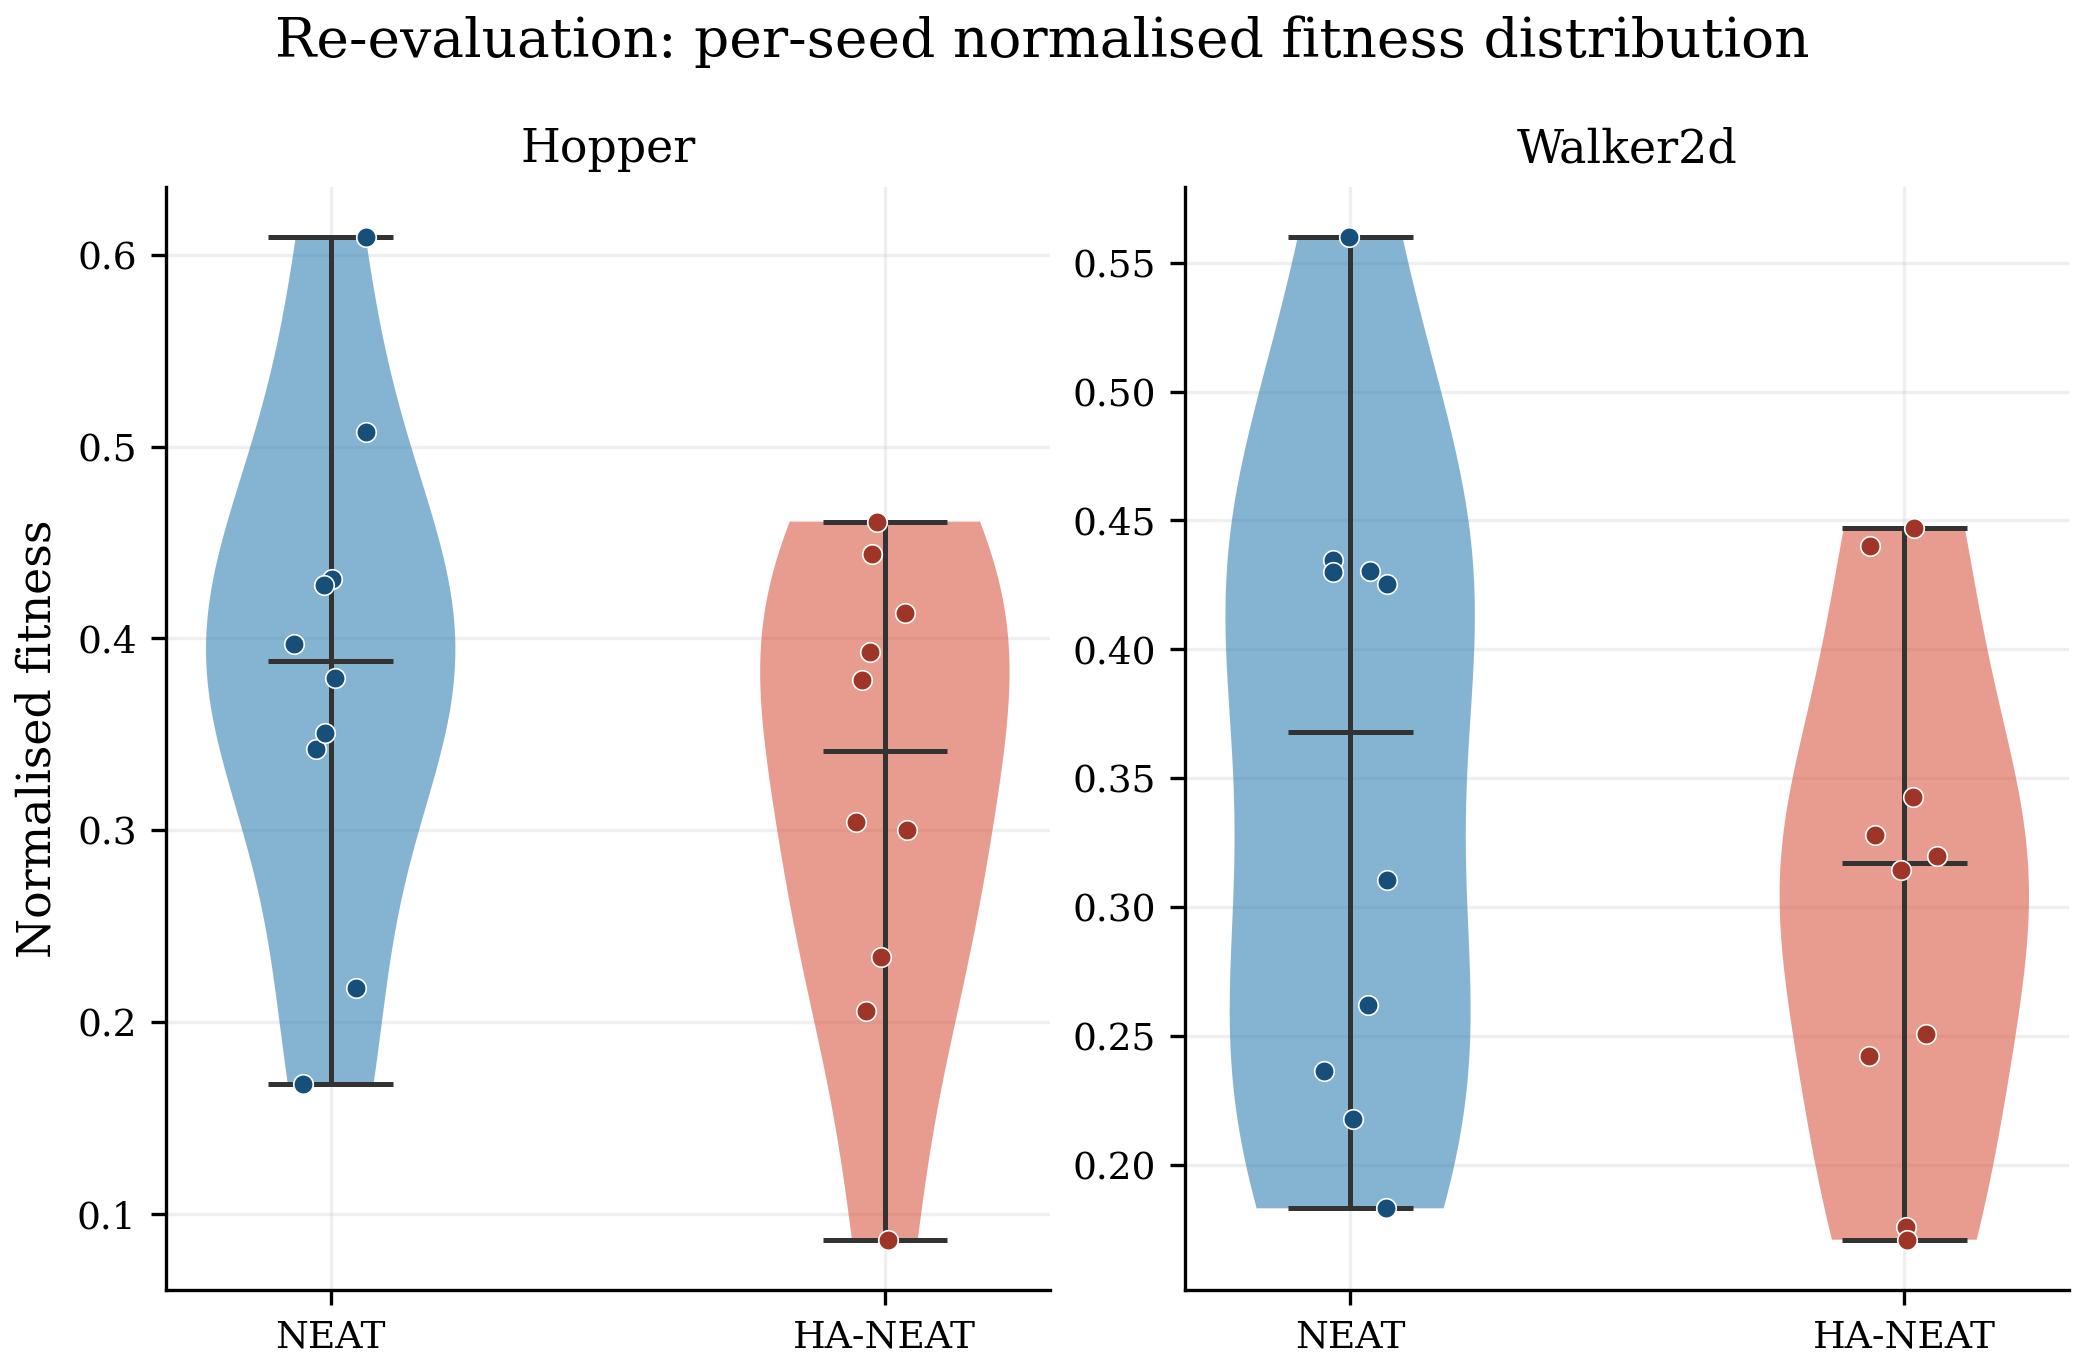

In [8]:
# 5b. Violin + strip distribution per task
def _seed_task_means(run_list, task):
    ref = REFERENCE_REWARDS.get(task, 1.0)
    return np.array([r["tasks"][task]["mean"] / ref
                     for r in run_list if task in r.get("tasks", {})])

fig, axes = plt.subplots(1, len(TASKS), figsize=(7, 4.5))
rng = np.random.default_rng(1)

for ax, task in zip(axes, TASKS):
    neat_vals = _seed_task_means(neat_runs, task)
    ha_vals   = _seed_task_means(ha_runs,   task)

    vp = ax.violinplot([neat_vals, ha_vals], positions=[0, 1],
                       showmedians=True, widths=0.45)
    colors = [ALGO_COLORS["neat"], ALGO_COLORS["ha_neat"]]
    for body, c in zip(vp["bodies"], colors):
        body.set_facecolor(c)
        body.set_alpha(0.55)
    for part in ["cbars", "cmins", "cmaxes", "cmedians"]:
        vp[part].set_color("#333333")
        vp[part].set_linewidth(1.2)

    for pos, vals, dc in zip([0, 1],
                              [neat_vals, ha_vals],
                              [ALGO_DOT_COLORS["neat"], ALGO_DOT_COLORS["ha_neat"]]):
        jitter = rng.uniform(-0.07, 0.07, len(vals))
        ax.scatter(np.full(len(vals), pos) + jitter, vals,
                   color=dc, s=22, zorder=5, edgecolors="white", linewidths=0.4)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["NEAT", "HA-NEAT"])
    ax.set_ylabel("Normalised fitness" if task == TASKS[0] else "")
    ax.set_title(task.capitalize())
    ax.yaxis.grid(True, alpha=0.3, color="#cccccc")
    ax.set_axisbelow(True)

fig.suptitle("Re-evaluation: per-seed normalised fitness distribution", y=1.01)
fig.tight_layout(pad=0.5)
fig.savefig(FIGURES_DIR / "distribution_violin.pdf")
print(f"  Saved: {FIGURES_DIR / 'distribution_violin.pdf'}")
plt.show()
plt.close(fig)

  Saved: /Users/svengoerdes/Projects/Thesisv2/tensorneat/analysis/outputs/final/figures/scatter_train_vs_reeval.pdf


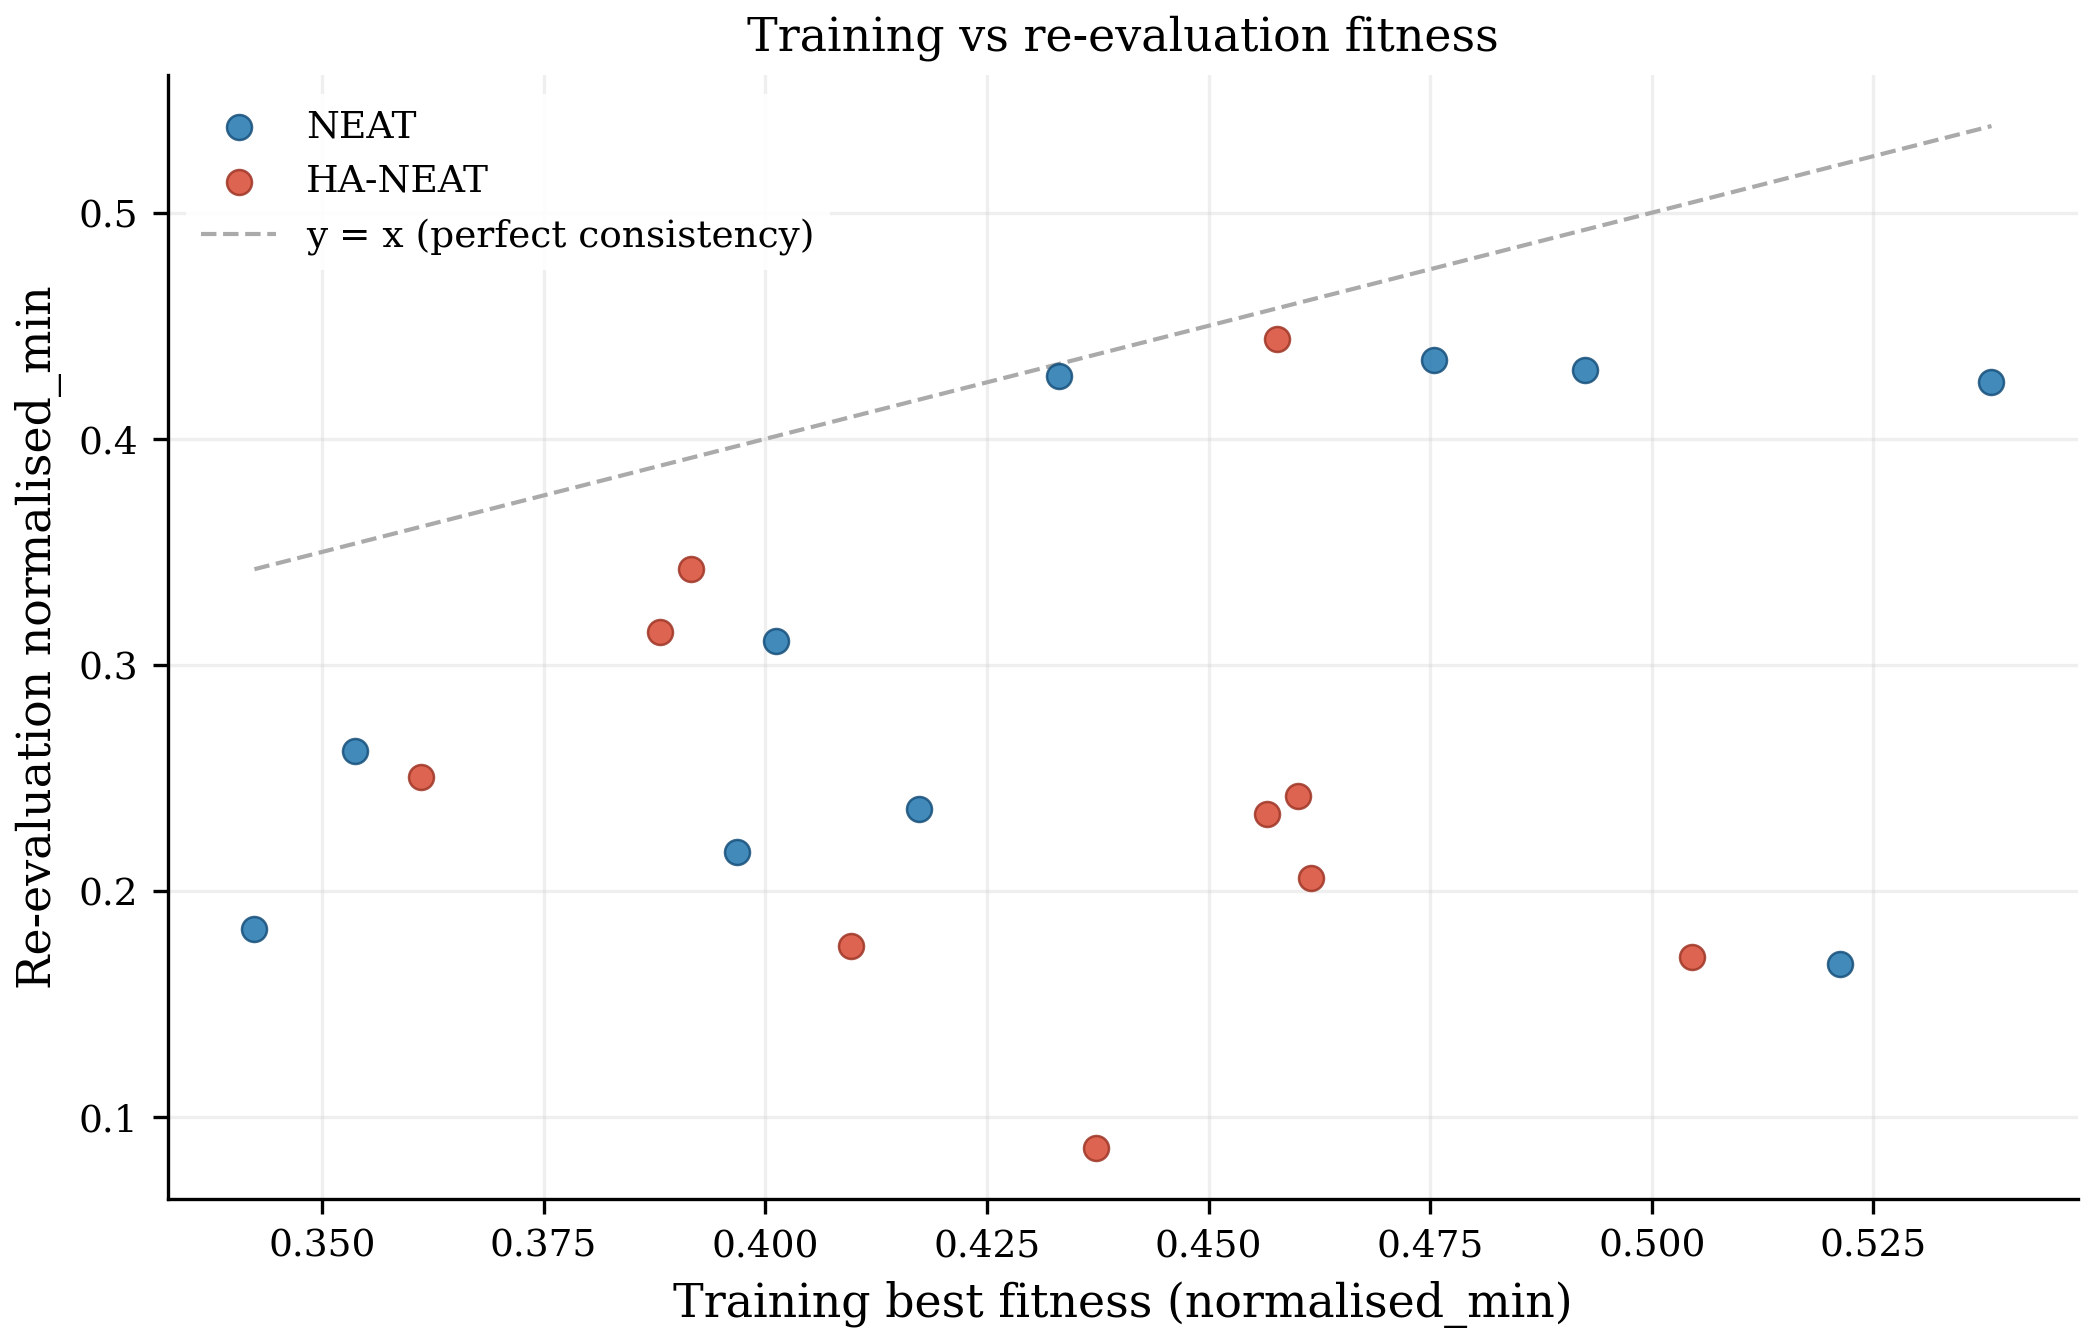

In [9]:
# 5c. Training best fitness vs re-eval normalized_min scatter
def _reeval_norm_min(run):
    norms = run.get("normalized", {})
    if "hopper" in norms and "walker2d" in norms:
        return min(norms["hopper"], norms["walker2d"])
    return None

fig, ax = plt.subplots(figsize=(7, 4.5))

for algo, run_list in [("neat", neat_runs), ("ha_neat", ha_runs)]:
    xs, ys = [], []
    for r in run_list:
        tf = r.get("training_fitness")
        nm = _reeval_norm_min(r)
        if tf is None or nm is None:
            continue
        xs.append(tf)
        ys.append(nm)
    ax.scatter(xs, ys,
               color=ALGO_COLORS[algo], label=ALGO_DISPLAY.get(algo, algo),
               s=36, edgecolors=ALGO_DOT_COLORS[algo], linewidths=0.6,
               zorder=4, alpha=0.85)

all_tf = [r["training_fitness"] for r in runs_ok if "training_fitness" in r]
if all_tf:
    lo, hi = min(all_tf), max(all_tf)
    ax.plot([lo, hi], [lo, hi], "--", color="#aaaaaa", linewidth=1.0,
            label="y = x (perfect consistency)", zorder=1)

ax.set_xlabel("Training best fitness (normalised_min)")
ax.set_ylabel("Re-evaluation normalised_min")
ax.set_title("Training vs re-evaluation fitness")
ax.legend(framealpha=0.9, edgecolor="none")
ax.yaxis.grid(True, alpha=0.3, color="#cccccc")
ax.set_axisbelow(True)
fig.tight_layout(pad=0.4)
fig.savefig(FIGURES_DIR / "scatter_train_vs_reeval.pdf")
print(f"  Saved: {FIGURES_DIR / 'scatter_train_vs_reeval.pdf'}")
plt.show()
plt.close(fig)

## 6. Statistical tests + bootstrap CIs

In [10]:
test_results = compute_tests(neat_runs, ha_runs, label_a="neat", label_b="ha_neat")
print(format_txt_report(test_results, label_a="NEAT", label_b="HA-NEAT"))

Statistical Comparison: NEAT vs HA-NEAT

  Task: HOPPER

  n: NEAT=10, HA-NEAT=10
  Mean: NEAT=1148.9 ± 384.4  HA-NEAT=965.9 ± 358.0
  Norm mean (/3000): NEAT=0.3830  HA-NEAT=0.3220

  1. Mann-Whitney U: U=62.0, p=0.3847

  2. Exact permutation test:
     observed diff=183.0, p=0.2843 (10000 permutations)

  3. Cohen's d: 0.493 (small)

  Task: WALKER2D

  n: NEAT=10, HA-NEAT=10
  Mean: NEAT=1745.1 ± 617.7  HA-NEAT=1515.6 ± 477.9
  Norm mean (/5000): NEAT=0.3490  HA-NEAT=0.3031

  1. Mann-Whitney U: U=56.0, p=0.6776

  2. Exact permutation test:
     observed diff=229.6, p=0.3635 (10000 permutations)

  3. Cohen's d: 0.416 (small)

  Task: NORMALIZED_MIN

  n: NEAT=10, HA-NEAT=10
  Mean: NEAT=0.3 ± 0.1  HA-NEAT=0.2 ± 0.1
  Norm mean (/1.0): NEAT=0.3096  HA-NEAT=0.2467

  1. Mann-Whitney U: U=63.0, p=0.3447

  2. Exact permutation test:
     observed diff=0.1, p=0.2016 (10000 permutations)

  3. Cohen's d: 0.595 (medium)



In [11]:
# Bootstrap 95% CIs (10 000 resamples)
def bootstrap_ci(values, stat=np.mean, n=10_000, seed=42, alpha=0.05):
    rng = np.random.default_rng(seed)
    arr = np.asarray(values)
    boots = [stat(rng.choice(arr, size=len(arr), replace=True)) for _ in range(n)]
    lo = np.percentile(boots, 100 * alpha / 2)
    hi = np.percentile(boots, 100 * (1 - alpha / 2))
    return float(lo), float(hi)

def format_ci(val, lo, hi, ref=1.0):
    return f"{val/ref:.4f} [{lo/ref:.4f}, {hi/ref:.4f}]"

table_rows = []
for task in TASKS + ["normalized_min"]:
    ref = REFERENCE_REWARDS.get(task, 1.0)
    r   = test_results[task]

    if task == "normalized_min":
        ma  = np.array(compute_normalized_min(neat_runs))
        mb  = np.array(compute_normalized_min(ha_runs))
        ref = 1.0
    else:
        ma = _seed_means(neat_runs, task)
        mb = _seed_means(ha_runs,   task)

    ci_a  = bootstrap_ci(ma)
    ci_b  = bootstrap_ci(mb)
    diffs = bootstrap_ci(mb - ma[:len(mb)])
    obs_diff = r["observed_diff"]

    table_rows.append({
        "Task"                 : task,
        "NEAT mean [95%CI]"    : format_ci(r["mean_a"], *ci_a, ref=ref),
        "HA-NEAT mean [95%CI]" : format_ci(r["mean_b"], *ci_b, ref=ref),
        "Δ mean [95%CI]"       : f"{obs_diff/ref:.4f} [{diffs[0]/ref:.4f}, {diffs[1]/ref:.4f}]",
        "Mann-Whitney p"       : f"{r['p_mannwhitney']:.4f}" if r['p_mannwhitney'] is not None else "n/a",
        "Permutation p"        : f"{r['p_permutation']:.4f}",
        "Cohen's d"            : f"{r['cohens_d']:.3f} ({r['magnitude']})",
    })

df_stats = pd.DataFrame(table_rows).set_index("Task")
display(df_stats)

,NEAT mean [95%CI],HA-NEAT mean [95%CI],Δ mean [95%CI],Mann-Whitney p,Permutation p,Cohen's d
Task,,,,,,
hopper,"0.3830 [0.3068, 0.4573]","0.3220 [0.2486, 0.3872]","0.0610 [-0.1812, 0.0548]",0.3847,0.2843,0.493 (small)
walker2d,"0.3490 [0.2777, 0.4204]","0.3031 [0.2467, 0.3596]","0.0459 [-0.1376, 0.0435]",0.6776,0.3635,0.416 (small)
normalized_min,"0.3096 [0.2455, 0.3741]","0.2467 [0.1890, 0.3067]","0.0629 [-0.1799, 0.0551]",0.3447,0.2016,0.595 (medium)


## 7. Summary

In [12]:
for f in sorted(FIGURES_DIR.glob("*")):
    print(f"  {f.relative_to(PROJECT_ROOT)}")

  analysis/outputs/final/figures/distribution_violin.pdf
  analysis/outputs/final/figures/genome_complexity.pdf
  analysis/outputs/final/figures/multi_task_neat_vs_haneat_final_evaluation.pdf
  analysis/outputs/final/figures/multi_task_neat_vs_haneat_final_evaluation_normalized.pdf
  analysis/outputs/final/figures/scatter_train_vs_reeval.pdf
  analysis/outputs/final/figures/training_aggregated.pdf
  analysis/outputs/final/figures/training_hopper.pdf
  analysis/outputs/final/figures/training_walker2d.pdf
